# Bayesian Nelson-Aalen: Gamma-Poisson Conjugate Model

This notebook introduces the **Bayesian nonparametric cumulative hazard estimator**
implemented in `bayes_survival.nonparametric.NelsonAalenModel`.

We work through:
1. The classic (frequentist) Nelson-Aalen estimator via `lifelines`
2. The Gamma-Poisson conjugate model — exact Bayesian inference, no MCMC
3. A side-by-side comparison on cumulative hazard and survival
4. How prior strength controls the degree of shrinkage

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import NelsonAalenFitter
from lifelines.datasets import load_leukemia

from bayes_survival.nonparametric import NelsonAalenModel

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. The Leukemia Dataset

Same Anderson (1982) leukemia dataset used in the KM notebook — 42 patients,
time to relapse in weeks, with right-censoring.

In [2]:
df = load_leukemia()

t     = df["t"].values
event = df["status"].values.astype(int)
eval_times = np.linspace(0, df["t"].max(), 300)

print(f"Observations : {len(df)}")
print(f"Events       : {int(event.sum())} ({event.mean():.1%})")
print(f"Time range   : {t.min():.0f} - {t.max():.0f} weeks")
df.head()

Observations : 42
Events       : 30 (71.4%)
Time range   : 1 - 35 weeks


,t,status,sex,logWBC,Rx
0,35,0,1,1.45,0
1,34,0,1,1.47,0
2,32,0,1,2.20,0
3,32,0,1,2.53,0
4,25,0,1,1.78,0


## 2. Frequentist Nelson-Aalen

The Nelson-Aalen estimator is the nonparametric maximum-likelihood estimate
of the **cumulative hazard function** $H(t) = \int_0^t h(u)\,du$.
At each observed event time $t_j$ it increments by:

$$\hat{H}(t) = \sum_{t_j \leq t} \frac{d_j}{n_j}$$

where $d_j$ is the number of events and $n_j$ the number at risk at $t_j$.
The survival function follows via $\hat{S}(t) = \exp(-\hat{H}(t))$.

Confidence intervals (shaded below) use the log-transformed variance formula.

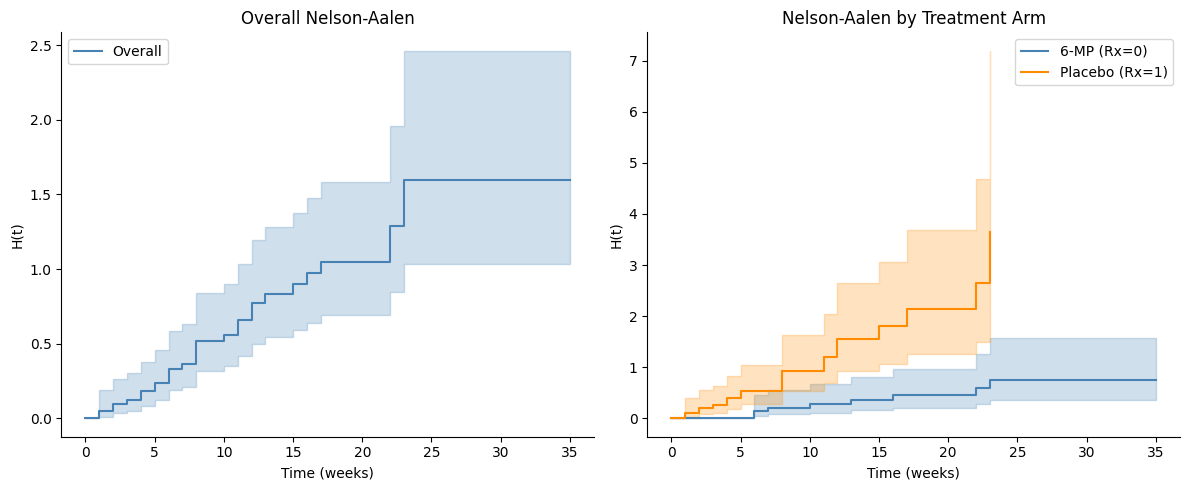

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall NA
ax = axes[0]
naf_all = NelsonAalenFitter()
naf_all.fit(t, event_observed=event, label="Overall")
naf_all.plot_cumulative_hazard(ax=ax, ci_show=True, color="steelblue")
ax.set_title("Overall Nelson-Aalen")
ax.set_xlabel("Time (weeks)")
ax.set_ylabel("H(t)")

# Stratified by treatment
ax = axes[1]
colors = {0: "steelblue", 1: "darkorange"}
labels = {0: "6-MP (Rx=0)", 1: "Placebo (Rx=1)"}
for rx_val in [0, 1]:
    mask = df["Rx"] == rx_val
    naf = NelsonAalenFitter()
    naf.fit(df.loc[mask, "t"], event_observed=df.loc[mask, "status"],
            label=labels[rx_val])
    naf.plot_cumulative_hazard(ax=ax, ci_show=True, color=colors[rx_val])
ax.set_title("Nelson-Aalen by Treatment Arm")
ax.set_xlabel("Time (weeks)")
ax.set_ylabel("H(t)")

plt.tight_layout()
plt.show()

## 3. Bayesian NA: the Gamma-Poisson Conjugate

### The model

Where the Bayesian KM placed a **Beta-Binomial** conjugate on each conditional
survival probability, Nelson-Aalen instead models the raw **event count** at
each time point. This calls for a different conjugate pair.

At each distinct event time $t_j$, the hazard increment
$\lambda_j$ (expected events per unit at-risk) is assigned a **Gamma prior**:

| Step | Expression |
|---|---|
| Prior | $\lambda_j \sim \mathrm{Gamma}(\alpha,\, \beta)$ |
| Likelihood | $d_j \mid \lambda_j \sim \mathrm{Poisson}(n_j \cdot \lambda_j)$ |
| Posterior | $\lambda_j \mid \text{data} \sim \mathrm{Gamma}(\alpha + d_j,\; \beta + n_j)$ |

Here $\beta$ is the **rate** parameter. The parameters $\alpha$ and $\beta$
act as pseudo-counts: $\alpha$ is virtual events and $\beta$ virtual
person-time injected before observing any data.

### Cumulative hazard and survival

Because the $\lambda_j$ are posterior-independent across event times:

$$H(t) = \sum_{t_j \leq t} \lambda_j \qquad S(t) = \exp(-H(t))$$

### Posterior mean (closed form)

$$E[H(t)] = \sum_{t_j \leq t} \frac{\alpha + d_j}{\beta + n_j}$$

As $\alpha, \beta \to 0$ this converges to the frequentist $\sum d_j / n_j$.

### Default prior: Gamma(0.1, 0.1)

The default places very little prior mass, letting the data dominate quickly.
Its effect is analogous to injecting 0.1 virtual events and 0.1 virtual
person-time at each step — negligible except in the tail where $n_j$ is small.

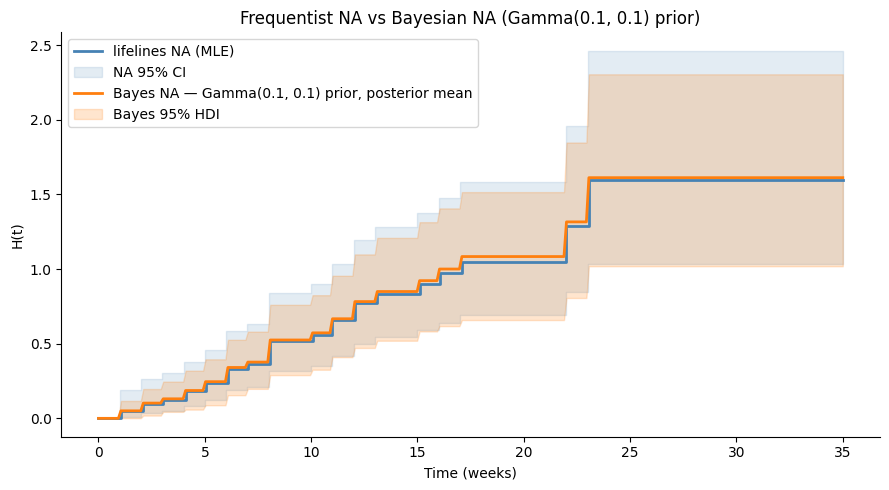

In [4]:
na_bay = NelsonAalenModel()   # Gamma(0.1, 0.1) default prior
na_bay.fit(t, event)

pred_H = na_bay.predict_cumulative_hazard(eval_times, hdi_prob=0.95)
na_ll_vals = naf_all.cumulative_hazard_at_times(eval_times).values
ci = naf_all.confidence_interval_

fig, ax = plt.subplots(figsize=(9, 5))

# lifelines NA
ax.step(eval_times, na_ll_vals, where="post", lw=2, color="steelblue",
        label="lifelines NA (MLE)")
ax.fill_between(
    ci.index,
    ci.iloc[:, 0],
    ci.iloc[:, 1],
    step="post", alpha=0.15, color="steelblue", label="NA 95% CI"
)

# Bayesian NA
ax.plot(eval_times, pred_H.mean[0], lw=2, color="C1",
        label=r"Bayes NA — Gamma(0.1, 0.1) prior, posterior mean")
ax.fill_between(
    eval_times, pred_H.hdi_lower[0], pred_H.hdi_upper[0],
    alpha=0.20, color="C1", label="Bayes 95% HDI"
)

ax.set_xlabel("Time (weeks)")
ax.set_ylabel("H(t)")
ax.set_title("Frequentist NA vs Bayesian NA (Gamma(0.1, 0.1) prior)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Survival Function Comparison

The Bayesian NA survival estimate $\hat{S}(t) = \exp(-\hat{H}(t))$ can be
compared directly to the KM curve. Because both are nonparametric, any
difference reflects the prior and the hazard-vs-survival parameterisation,
not a distributional assumption.

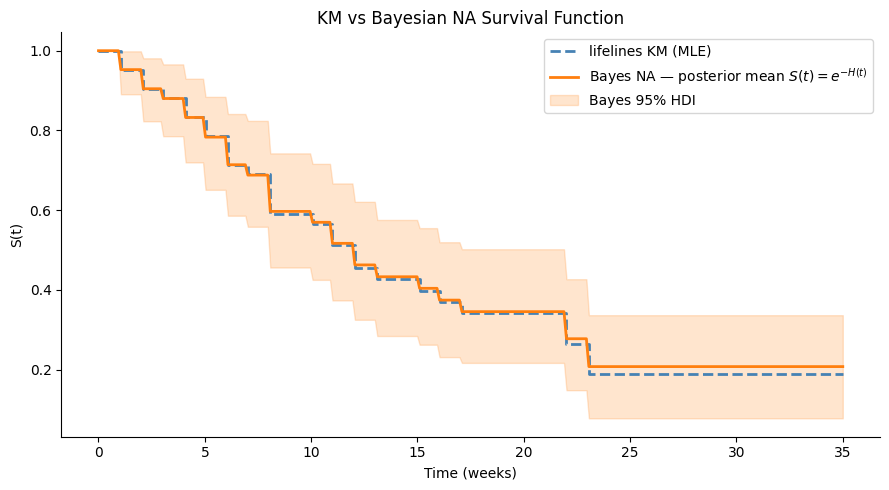

In [5]:
from lifelines import KaplanMeierFitter

pred_S = na_bay.predict_survival_function(eval_times, hdi_prob=0.95)

kmf = KaplanMeierFitter()
kmf.fit(t, event_observed=event)
km_vals = kmf.survival_function_at_times(eval_times).values

fig, ax = plt.subplots(figsize=(9, 5))

# KM reference
ax.step(eval_times, km_vals, where="post", lw=2, color="steelblue",
        ls="--", label="lifelines KM (MLE)")

# Bayesian NA survival
ax.plot(eval_times, pred_S.mean[0], lw=2, color="C1",
        label=r"Bayes NA — posterior mean $S(t) = e^{-H(t)}$")
ax.fill_between(
    eval_times, pred_S.hdi_lower[0], pred_S.hdi_upper[0],
    alpha=0.20, color="C1", label="Bayes 95% HDI"
)

ax.set_xlabel("Time (weeks)")
ax.set_ylabel("S(t)")
ax.set_title("KM vs Bayesian NA Survival Function")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Per-Step Comparison

The hazard increment formulas side-by-side:

| Model | Increment at $t_j$ |
|---|---|
| NA (MLE) | $d_j / n_j$ |
| Bayesian, $\alpha = \beta = 0.1$ | $(0.1 + d_j) / (0.1 + n_j)$ |

The Bayesian increment is larger whenever $\alpha / \beta > d_j / n_j$, i.e.
when the prior ratio exceeds the observed hazard — which with $\alpha = \beta$
means the prior pulls toward hazard = 1, inflating estimates when $d_j / n_j$
is small. The relative effect grows as $n_j$ shrinks, so the gap widens
at **late time points** exactly where the MLE is least reliable.

In [6]:
rt = na_bay._risk_table

alpha_p, beta_p = na_bay.priors["h"]
na_increment    = rt.n_events / rt.n_at_risk
bayes_increment = (alpha_p + rt.n_events) / (beta_p + rt.n_at_risk)

comparison = pd.DataFrame({
    "time"            : rt.times,
    "n_at_risk"       : rt.n_at_risk,
    "n_events"        : rt.n_events,
    "NA increment"    : na_increment.round(5),
    "Bayes increment" : bayes_increment.round(5),
    "diff"            : (bayes_increment - na_increment).round(5),
})
print(f"Hazard increment per step: NA (MLE) vs Bayesian Gamma({alpha_p}, {beta_p})")
comparison

Hazard increment per step: NA (MLE) vs Bayesian Gamma(0.1, 0.1)


,time,n_at_risk,n_events,NA increment,Bayes increment,diff
0,1.0,42,2,0.04762,0.04988,0.00226
1,2.0,40,2,0.05000,0.05237,0.00237
2,3.0,38,1,0.02632,0.02887,0.00256
3,4.0,37,2,0.05405,0.05660,0.00255
4,5.0,35,2,0.05714,0.05983,0.00269
5,6.0,33,3,0.09091,0.09366,0.00275
6,7.0,29,1,0.03448,0.03780,0.00332
7,8.0,28,4,0.14286,0.14591,0.00305
8,10.0,23,1,0.04348,0.04762,0.00414
9,11.0,21,2,0.09524,0.09953,0.00429


## 6. Effect of Prior Strength

Setting $\alpha = \beta$ keeps the prior symmetric in its effect on
the posterior mean hazard increment. Reducing their magnitude weakens the prior:

| Prior | Character |
|---|---|
| Gamma(1.0, 1.0) | Exponential(1) — moderately informative |
| Gamma(0.5, 0.5) | Weaker |
| Gamma(0.1, 0.1) | Near-vague — default |
| Gamma(0.01, 0.01) | Near-MLE |

As $\alpha, \beta \to 0$ each increment converges to $d_j / n_j$ and the
posterior mean cumulative hazard converges to the frequentist Nelson-Aalen.

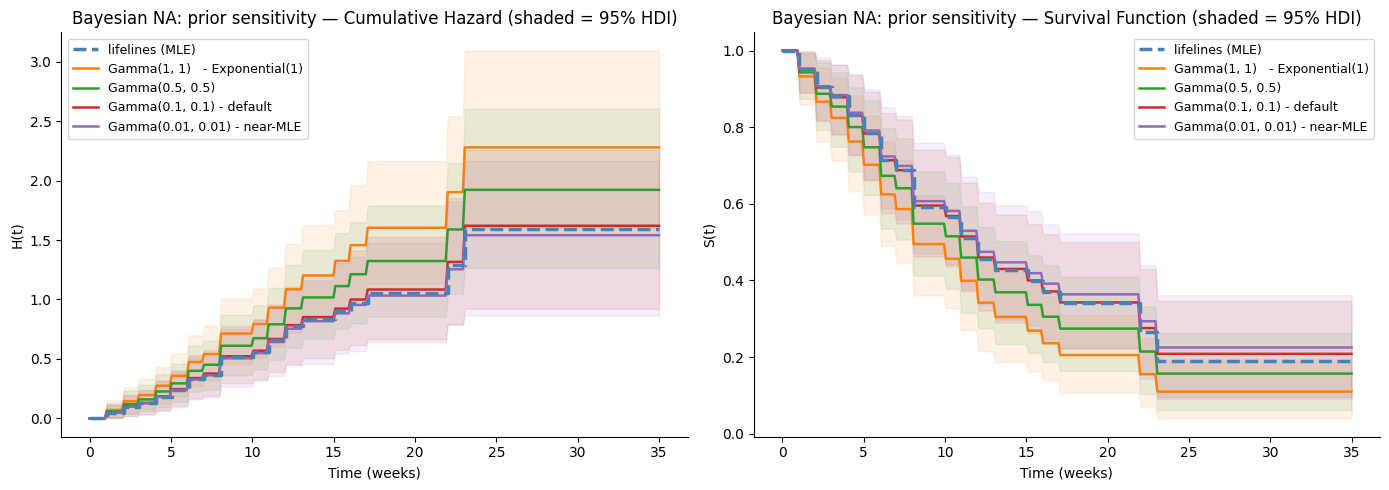

In [7]:
priors = [
    ((1.0,  1.0),  "C1", "Gamma(1, 1)   - Exponential(1)"),
    ((0.5,  0.5),  "C2", "Gamma(0.5, 0.5)"),
    ((0.1,  0.1),  "C3", "Gamma(0.1, 0.1) - default"),
    ((0.01, 0.01), "C4", "Gamma(0.01, 0.01) - near-MLE"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (getter, ylabel, title) in zip(axes, [
    (lambda m, et: m.predict_cumulative_hazard(et, hdi_prob=0.95), "H(t)", "Cumulative Hazard"),
    (lambda m, et: m.predict_survival_function(et, hdi_prob=0.95), "S(t)", "Survival Function"),
]):
    # Frequentist reference
    ref_vals = (naf_all.cumulative_hazard_at_times(eval_times).values
                if ylabel == "H(t)" else km_vals)
    ax.step(eval_times, ref_vals, where="post", lw=2.5, color="steelblue",
            ls="--", label="lifelines (MLE)", zorder=5)

    for (a, b), color, label in priors:
        na_p = NelsonAalenModel(priors={"h": (a, b)})
        na_p.fit(t, event)
        pred = getter(na_p, eval_times)
        ax.plot(eval_times, pred.mean[0], lw=1.8, color=color, label=label)
        ax.fill_between(eval_times, pred.hdi_lower[0], pred.hdi_upper[0],
                        alpha=0.10, color=color)

    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Bayesian NA: prior sensitivity — {title} (shaded = 95% HDI)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Asymmetric Priors

Setting $\alpha \neq \beta$ encodes directional prior knowledge about the
hazard level at each time point. With $\alpha < \beta$ the prior mean
$\alpha / \beta < 1$ shrinks each increment downward — encoding the belief
that the event rate per person-time is low. With $\alpha > \beta$ the prior
pushes toward higher hazard.

As with the KM model, this prior applies **independently at every event time** —
it is a local claim about the instantaneous hazard, not a global statement
about total burden.

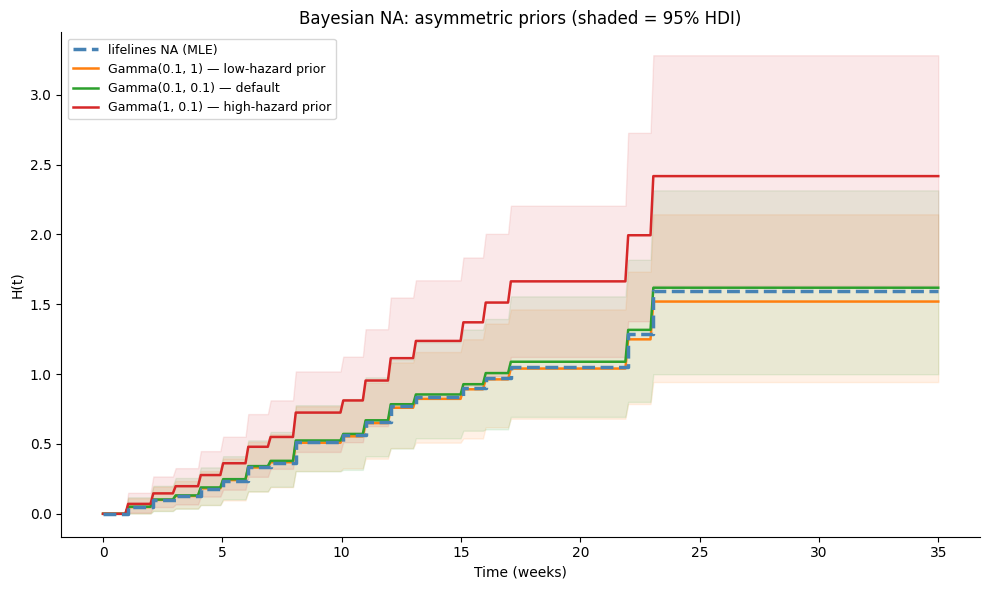

In [8]:
priors_asym = [
    ((0.1,  1.0), "C1", r"Gamma(0.1, 1) — low-hazard prior"),
    ((0.1,  0.1), "C2", r"Gamma(0.1, 0.1) — default"),
    ((1.0,  0.1), "C3", r"Gamma(1, 0.1) — high-hazard prior"),
]

fig, ax = plt.subplots(figsize=(10, 6))

# Frequentist NA reference
ax.step(eval_times, na_ll_vals, where="post", lw=2.5, color="steelblue",
        ls="--", label="lifelines NA (MLE)", zorder=5)

for (a, b), color, label in priors_asym:
    na_p = NelsonAalenModel(priors={"h": (a, b)})
    na_p.fit(t, event)
    pred = na_p.predict_cumulative_hazard(eval_times, hdi_prob=0.95)
    ax.plot(eval_times, pred.mean[0], lw=1.8, color=color, label=label)
    ax.fill_between(eval_times, pred.hdi_lower[0], pred.hdi_upper[0],
                    alpha=0.10, color=color)

ax.set_xlabel("Time (weeks)")
ax.set_ylabel("H(t)")
ax.set_title("Bayesian NA: asymmetric priors (shaded = 95% HDI)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()